In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('creditcard.csv')

print("Shape:", df.shape)
print("\nClass Distribution:\n", df['Class'].value_counts())
print("\nMissing Values:", df.isnull().sum().sum())

Shape: (284807, 31)

Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Missing Values: 0


Before SMOTE:
Class
0    284315
1       492
Name: count, dtype: int64

After SMOTE:
Class
0    284315
1    284315
Name: count, dtype: int64


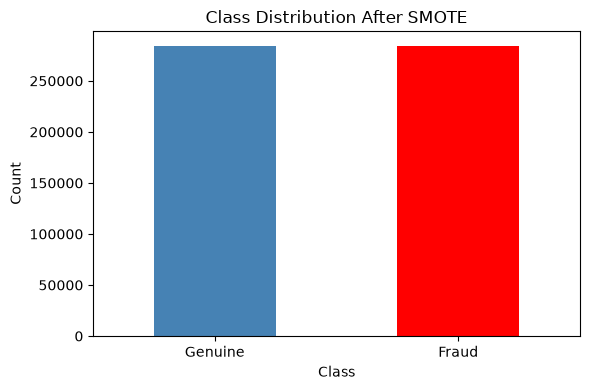

In [3]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time']   = scaler.fit_transform(df[['Time']])

X = df.drop('Class', axis=1)
y = df['Class']

print("Before SMOTE:")
print(y.value_counts())

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(pd.Series(y_res).value_counts())

plt.figure(figsize=(6,4))
pd.Series(y_res).value_counts().plot(
    kind='bar', color=['steelblue','red'])
plt.title('Class Distribution After SMOTE')
plt.xticks([0,1], ['Genuine','Fraud'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Training size: (454904, 30)
Testing size : (113726, 30)

Training: Logistic Regression
              precision    recall  f1-score   support

     Genuine       0.93      0.98      0.95     56750
       Fraud       0.97      0.92      0.95     56976

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726

ROC-AUC : 0.9896


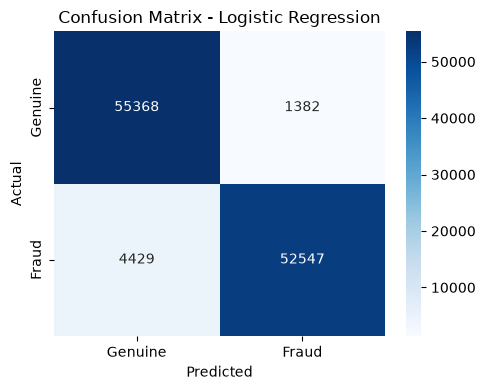


Training: Random Forest


KeyboardInterrupt: 

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size :", X_test.shape)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")

    model.fit(X_train, y_train)

    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:,1]

    report  = classification_report(
        y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    ap      = average_precision_score(
        y_test, y_pred_prob)

    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_pred_prob,
        'precision': report['1']['precision'],
        'recall'   : report['1']['recall'],
        'f1'       : report['1']['f1-score'],
        'roc_auc'  : roc_auc,
        'avg_prec' : ap
    }

    print(classification_report(
        y_test, y_pred,
        target_names=['Genuine','Fraud']))
    print(f"ROC-AUC : {roc_auc:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues',
                xticklabels=['Genuine','Fraud'],
                yticklabels=['Genuine','Fraud'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


MODEL COMPARISON SUMMARY
                     Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.9744  0.9223    0.9476   0.9896


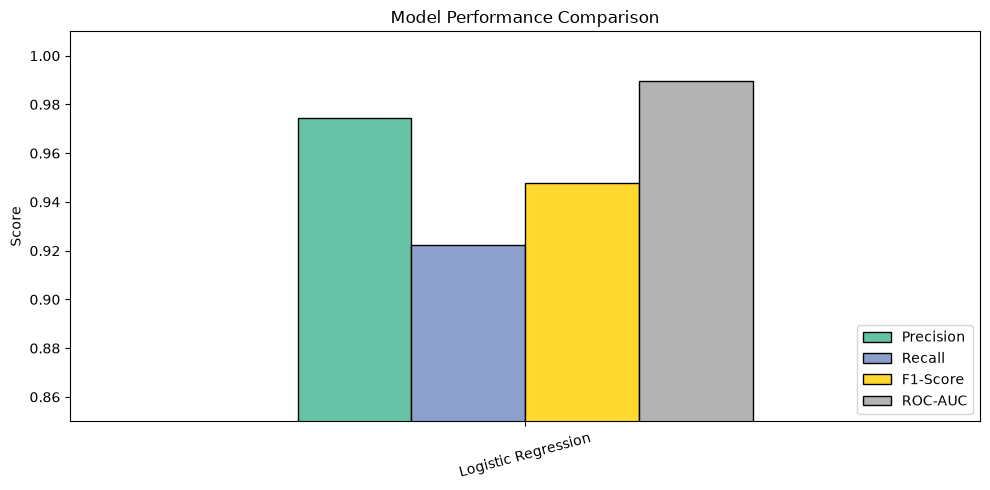

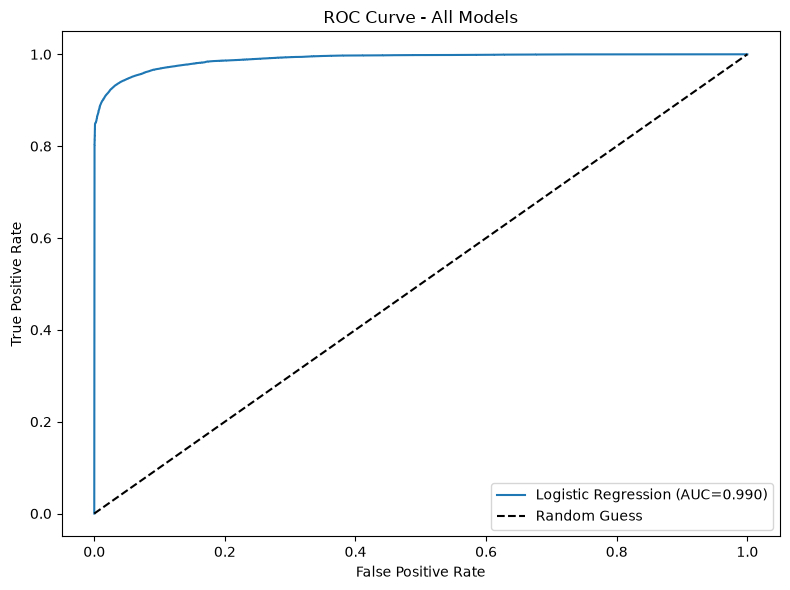


Best Model : Logistic Regression
F1-Score   : 0.9476
ROC-AUC    : 0.9896


In [5]:
summary = pd.DataFrame({
    name: {
        'Precision': round(r['precision'], 4),
        'Recall'   : round(r['recall'],    4),
        'F1-Score' : round(r['f1'],        4),
        'ROC-AUC'  : round(r['roc_auc'],   4)
    }
    for name, r in results.items()
}).T

print("\nMODEL COMPARISON SUMMARY")
print("="*50)
print(summary)

summary.plot(kind='bar', figsize=(10,5),
             colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.85, 1.01)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr,
             label=f"{name} (AUC={r['roc_auc']:.3f})")
plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend()
plt.tight_layout()
plt.show()

best_name  = max(results,
                 key=lambda x: results[x]['f1'])
best_model = results[best_name]['model']
print(f"\nBest Model : {best_name}")
print(f"F1-Score   : {results[best_name]['f1']:.4f}")
print(f"ROC-AUC    : {results[best_name]['roc_auc']:.4f}")

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 5],
    'learning_rate': [0.1, 0.2]
}

xgb_tuned = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42)

grid_search = GridSearchCV(
    xgb_tuned,
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best F1 Score  :",
      round(grid_search.best_score_, 4))

final_model  = grid_search.best_estimator_
y_final_pred = final_model.predict(X_test)

print("\nFinal Tuned Model:")
print(classification_report(
    y_test, y_final_pred,
    target_names=['Genuine','Fraud']))
print("ROC-AUC:", round(roc_auc_score(
    y_test,
    final_model.predict_proba(X_test)[:,1]), 4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Best F1 Score  : 0.9996

Final Tuned Model:
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56750
       Fraud       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC-AUC: 1.0


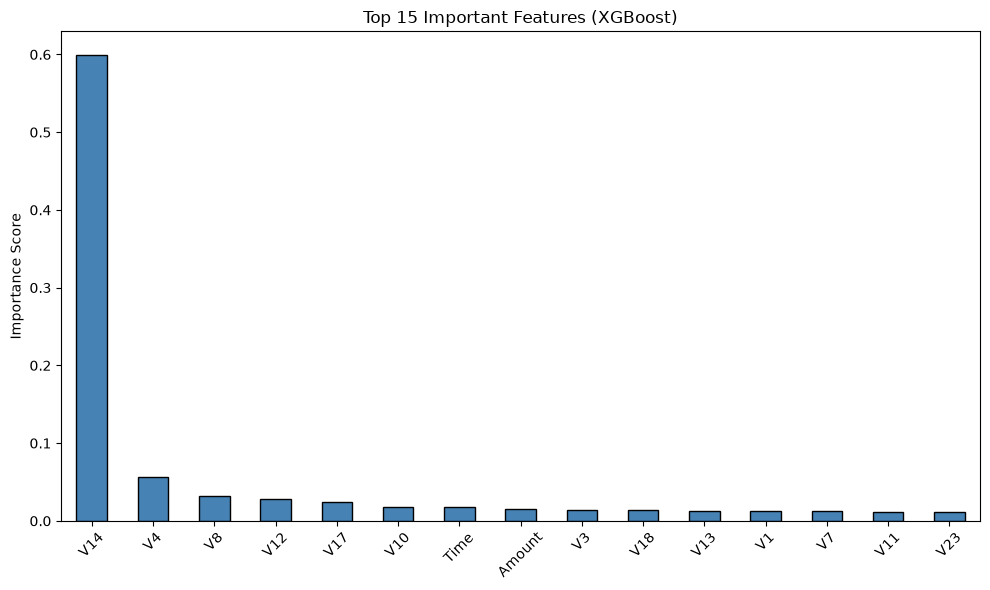

Top 10 Features:
 V14       0.599753
V4        0.055787
V8        0.032152
V12       0.028690
V17       0.024198
V10       0.018235
Time      0.017454
Amount    0.014921
V3        0.013962
V18       0.013862
dtype: float32


In [7]:
importance = pd.Series(
    final_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance[:15].plot(kind='bar',
                     color='steelblue',
                     edgecolor='black')
plt.title('Top 15 Important Features (XGBoost)')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Top 10 Features:\n", importance[:10])

In [8]:
import joblib

joblib.dump(final_model, 'fraud_detection_model.pkl')
joblib.dump(scaler,      'scaler.pkl')
print("Model and scaler saved successfully ✅")

loaded_model  = joblib.load(
    'fraud_detection_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
print("Model and scaler loaded successfully ✅")

Model and scaler saved successfully ✅
Model and scaler loaded successfully ✅


In [11]:
def predict_transaction(transaction_data):
    input_df = pd.DataFrame([transaction_data])

    prediction  = final_model.predict(input_df)
    probability = final_model.predict_proba(input_df)

    fraud_prob   = round(probability[0][1] * 100, 2)
    genuine_prob = round(probability[0][0] * 100, 2)

    print("\n" + "="*40)
    print("  TRANSACTION ANALYSIS RESULT")
    print("="*40)

    if prediction[0] == 1:
        print("  ⚠️  STATUS : FRAUDULENT TRANSACTION")
    else:
        print("  ✅  STATUS : GENUINE TRANSACTION")

    print(f"  Fraud Probability   : {fraud_prob}%")
    print(f"  Genuine Probability : {genuine_prob}%")
    print("="*40)

    return prediction[0], fraud_prob


# Test single transaction
sample = dict(zip(X_test.columns,
                  X_test.iloc[0].values))
predict_transaction(sample)

# Test 5 transactions
print("\n--- BATCH PREDICTION ---")
for i in range(5):
    sample = dict(zip(X_test.columns,
                      X_test.iloc[i].values))
    predict_transaction(sample)


  TRANSACTION ANALYSIS RESULT
  ⚠️  STATUS : FRAUDULENT TRANSACTION
  Fraud Probability   : 100.0%
  Genuine Probability : 0.0%

--- BATCH PREDICTION ---

  TRANSACTION ANALYSIS RESULT
  ⚠️  STATUS : FRAUDULENT TRANSACTION
  Fraud Probability   : 100.0%
  Genuine Probability : 0.0%

  TRANSACTION ANALYSIS RESULT
  ⚠️  STATUS : FRAUDULENT TRANSACTION
  Fraud Probability   : 100.0%
  Genuine Probability : 0.0%

  TRANSACTION ANALYSIS RESULT
  ✅  STATUS : GENUINE TRANSACTION
  Fraud Probability   : 0.0%
  Genuine Probability : 100.0%

  TRANSACTION ANALYSIS RESULT
  ⚠️  STATUS : FRAUDULENT TRANSACTION
  Fraud Probability   : 100.0%
  Genuine Probability : 0.0%

  TRANSACTION ANALYSIS RESULT
  ⚠️  STATUS : FRAUDULENT TRANSACTION
  Fraud Probability   : 100.0%
  Genuine Probability : 0.0%
